# **Modelling and Evaluation Notebook**

## Objectives

* Answer business requirement 2:
  * The client is interested in predicting if a cherry leaf is healthy or contains powdery mildew.

## Inputs

* inputs/cherry_leaves_dataset/train
* inputs/cherry_leaves_dataset/test
* inputs/cherry_leaves_dataset/validation
* image shape embeddings.

## Outputs

* Images distribution plot in train, validation, and test set.
* Image augmentation.
* Class indices to change prediction inference in labels.
* Machine learning model creation and training.
* Save model.
* Learning curve plot for model performance.
* Model evaluation on pickle file.
* Prediction on the random image file.

## Additional Comments




---

# Import regular packages

In [1]:
%load_ext pycodestyle_magic
%pycodestyle_on

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Set working directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/project_5_mildew_detection/jupyter_notebooks'

In [4]:
os.chdir('/workspaces/project_5_mildew_detection')
current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Working directory set to: /workspaces/project_5_mildew_detection


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'/workspaces/project_5_mildew_detection'

# Set input directories

Set train, validation and test paths

In [6]:
my_data_dir = 'inputs/cherry_leaves_dataset'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

# Set output directories

In [7]:
version = 'v1'
file_path = f'outputs/{version}'

if os.path.exists(file_path):
    print(f"Old version '{version}' already exists. Create a new version.")
else:
    os.makedirs(file_path)
    print(f"Created folder: {file_path}")

Old version 'v1' already exists. Create a new version.


# Set labels

In [8]:
labels = os.listdir(train_path)

print(
    f"Project Labels: {labels}"
)

Project Labels: ['powdery_mildew', 'healthy']


# Set image shape

In [9]:
# Import saved image shape embedding
import joblib
version = 'v1'
image_shape = joblib.load(filename=f"outputs/{version}/image_shape.pkl")
image_shape

(256, 256, 3)

---

# Number of images in train, test and validation data

* train - powdery_mildew: 1472 images
* train - healthy: 1472 images
* validation - powdery_mildew: 210 images
* validation - healthy: 210 images
* test - powdery_mildew: 422 images
* test - healthy: 422 images




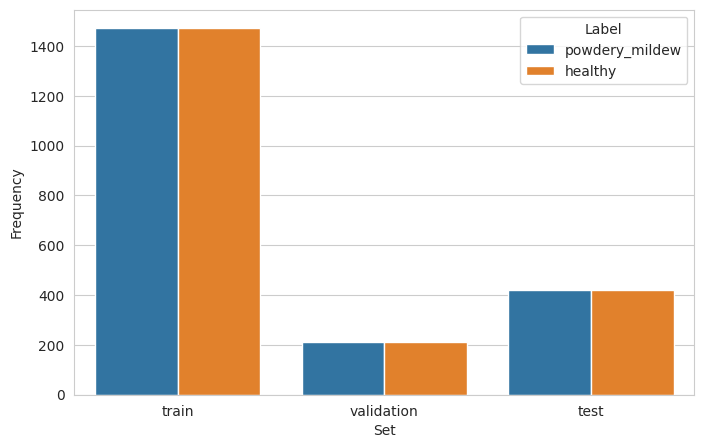

In [10]:
import pandas as pd

# Create an empty dictionary
data = {
    'Set': [],
    'Label': [],
    'Frequency': []
}

# Define the number of rows you want to create
folders = ['train', 'validation', 'test']

# Loop to dynamically create and append rows to the dictionary
for folder in folders:
    for label in labels:
        row = {
            'Set': folder,
            'Label': label,
            'Frequency': int(
                len(os.listdir(os.path.join(my_data_dir, folder, label)))
            )
        }
        for key, value in row.items():
            data[key].append(value)
        print(
            f"* {folder} - {label}: "
            f"{len(os.listdir(os.path.join(my_data_dir, folder, label)))} "
            f"images"
        )

# Convert the dictionary to a DataFrame
df_freq = pd.DataFrame(data)

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

---

# Image data augmentation

## ImageDataGenerator

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-07-16 06:13:41.901710: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-16 06:13:54.018291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-16 06:14:04.794706: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


* ## Initialize ImageDataGenerator

In [12]:
augment_image_data = ImageDataGenerator(rotation_range=20,
                                        width_shift_range=0.10,
                                        height_shift_range=0.10,
                                        shear_range=0.1,
                                        zoom_range=0.1,
                                        horizontal_flip=True,
                                        vertical_flip=True,
                                        fill_mode='nearest',
                                        rescale=1./255
                                        )

* ## Augment training image dataset

In [13]:
sample_size = 8  # Set sample size
augmented_train_data = augment_image_data.flow_from_directory(
    train_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=sample_size,
    class_mode='binary',
    shuffle=True
)

augmented_train_data.class_indices

Found 2944 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

* ## Augment validation image dataset

In [14]:
validate_set = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    val_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=sample_size,
    class_mode='binary',
    shuffle=False
)

validate_set.class_indices

Found 420 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

* ## Augment test image dataset 

In [15]:
test_image_set = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    test_path,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=sample_size,
    class_mode='binary',
    shuffle=False
)

test_image_set.class_indices

Found 844 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

## Plot augmented training image

(8, 256, 256, 3)


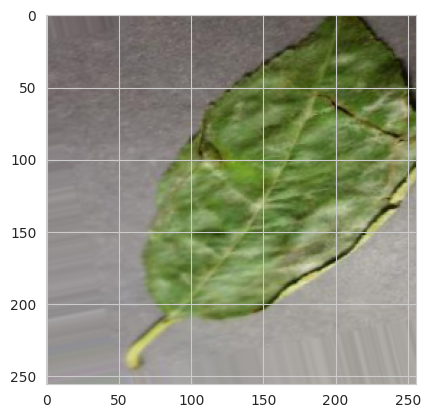

(8, 256, 256, 3)


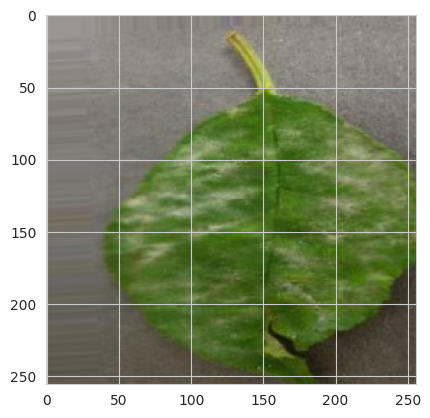

(8, 256, 256, 3)


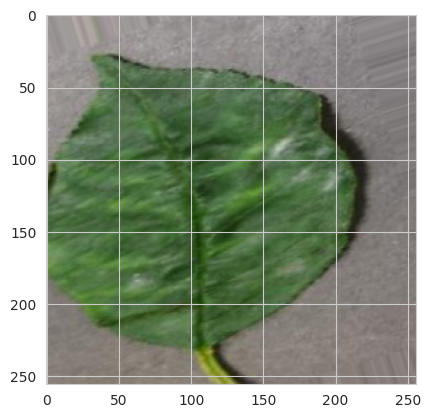

In [16]:
for _ in range(3):
    img, label = next(augmented_train_data)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

## Plot augmented validation and test images

(8, 256, 256, 3)


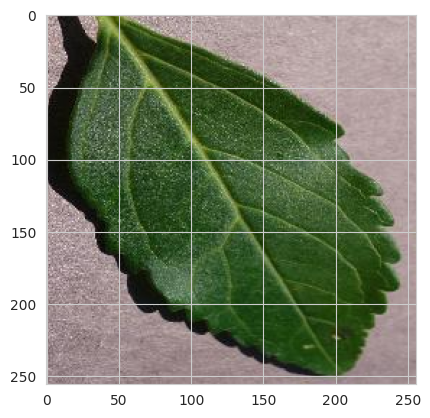

(8, 256, 256, 3)


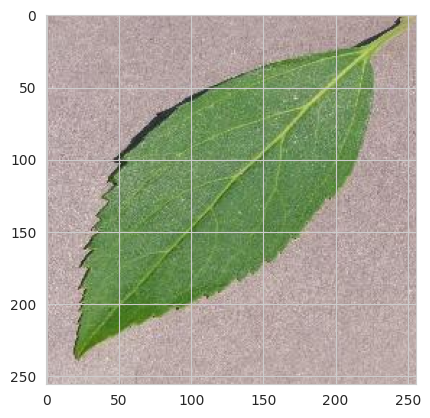

(8, 256, 256, 3)


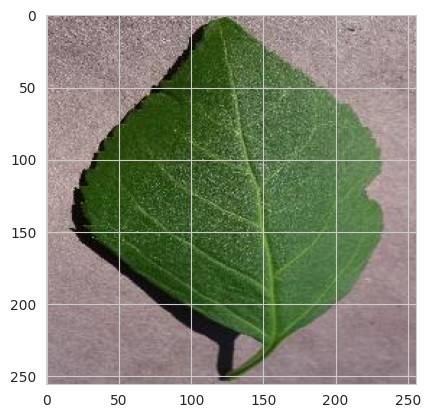

In [17]:
for _ in range(3):
    img, label = next(validate_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

(8, 256, 256, 3)


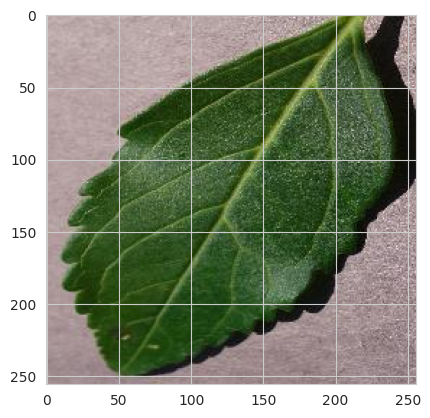

(8, 256, 256, 3)


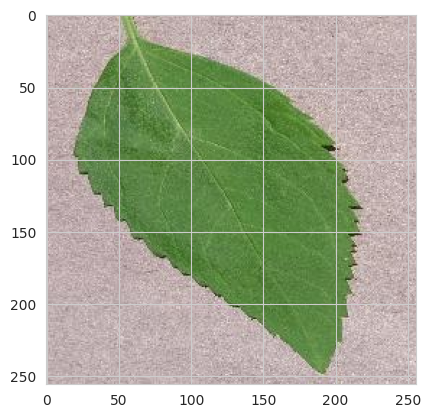

(8, 256, 256, 3)


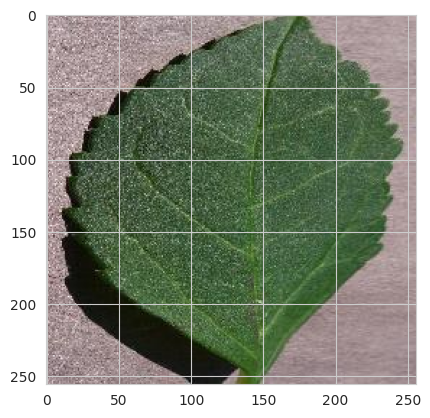

In [18]:
for _ in range(3):
    img, label = next(test_image_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

## Save class_indices

In [19]:
joblib.dump(value=augmented_train_data.class_indices,
            filename=f"{file_path}/class_indices.pkl")

['outputs/v1/class_indices.pkl']

---

# Model creation

---

## ML model

* ### Import model packages

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dropout,
    Flatten,
    Dense,
    Conv2D,
    MaxPooling2D,
    Input
)

* ### Model

In [21]:
def cherry_leaf_model(image_shape=(256, 256, 3)):
    model = Sequential()
    model.add(Input(shape=image_shape))  # Explicit input layer

    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

* ### Model Summary 

In [22]:
cherry_leaf_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,429,377 (28.34 MB)

 Trainable params: 7,429,377 (28.34 MB)

 Non-trainable params: 0 (0.00 B)

* ### Early Stopping

In [23]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

## Fit model for model training

In [ ]:
model = cherry_leaf_model()
model.fit(
    augmented_train_data,
    epochs=25,
    steps_per_epoch=len(augmented_train_data.classes) // sample_size,
    validation_data=validate_set,
    callbacks=[early_stop],
    verbose=1
)

/home/cistudent/.pyenv/versions/3.9.18/envs/jupyter-py39/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 132s 352ms/step - accuracy: 0.7333 - loss: 0.5475 - val_accuracy: 0.9667 - val_loss: 0.1285
Epoch 2/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 127s 345ms/step - accuracy: 0.9651 - loss: 0.1203 - val_accuracy: 0.9810 - val_loss: 0.1271
Epoch 3/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 131s 357ms/step - accuracy: 0.9779 - loss: 0.0816 - val_accuracy: 0.9881 - val_loss: 0.0286
Epoch 4/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 127s 345ms/step - accuracy: 0.9656 - loss: 0.0958 - val_accuracy: 0.9976 - val_loss: 0.0098
Epoch 5/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 141s 343ms/step - accuracy: 0.9781 - loss: 0.0765 - val_accuracy: 0.9976 - val_loss: 0.0166
Epoch 6/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 126s 342ms/step - accuracy: 0.9956 - loss: 0.0162 - val_accuracy: 0.9929 - val_loss: 0.0112
Epoch 7/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 134s 364ms/step - accuracy: 0.9896 - loss: 0.0374 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 8/25
368/368 ━━━━━━━━━━━━━━━━━━━━ 126s 343ms/step - accuracy: 0.9903 -

### Save model

In [ ]:
model.save("outputs/v1/powdery_mildew_model.h5")

---

# Model Performance

---

## Model learning curve

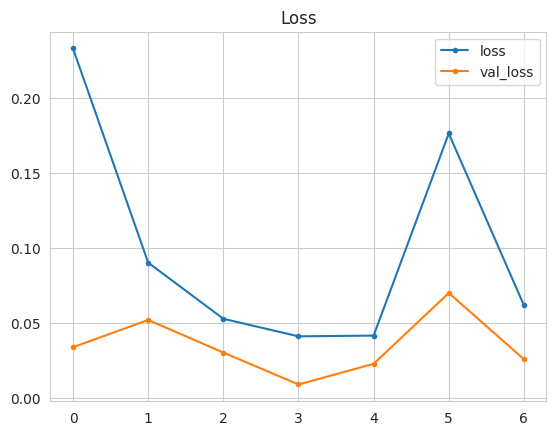

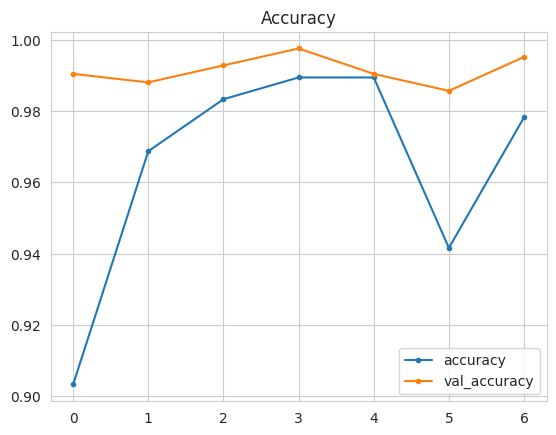

In [ ]:
losses = pd.DataFrame(model.history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{file_path}/model_training_losses.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{file_path}/model_training_acc.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Model Evaluation

In [ ]:
from keras.models import load_model
model = load_model("outputs/v1/powdery_mildew_model.h5")

Evaluate model on test set

In [ ]:
evaluation = model.evaluate(test_image_set)

/home/cistudent/.pyenv/versions/3.9.18/envs/jupyter-py39/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.9989 - loss: 0.0029


## Save evaluation pickle

In [ ]:
joblib.dump(value=evaluation,
            filename=f"outputs/v1/evaluation.pkl")

['outputs/v1/evaluation.pkl']

## Predict on new data

Load a random image as PIL

Image shape: (256, 256), Image mode: RGB


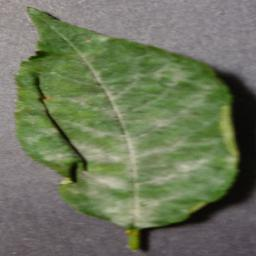

In [ ]:
from tensorflow.keras.preprocessing import image

pointer = 66
label = labels[0]  # select Uninfected or Parasitised

pil_image = image.load_img(
    test_path + '/' + label + '/' +
    os.listdir(test_path + '/' + label)[pointer],
    target_size=image_shape,
    color_mode='rgb'
)
print(f'Image shape: {pil_image.size}, Image mode: {pil_image.mode}')
pil_image

Convert image to array and prepare for prediction

In [ ]:
leaf_image = image.img_to_array(pil_image)
leaf_image = np.expand_dims(leaf_image, axis=0)/255
print(leaf_image.shape)

(1, 256, 256, 3)


Predict class probabilities

In [ ]:
pred_proba = model.predict(leaf_image)[0, 0]

target_map = {v: k for k, v in augmented_train_data.class_indices.items()}
pred_class = target_map[pred_proba > 0.5]

if pred_class == target_map[0]:
    pred_proba = 1 - pred_proba

print(pred_proba)
print(pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
0.99999386
powdery_mildew


---

# Push files to Repo

In [ ]:
!cat .gitignore

core.Microsoft*
core.mongo*
core.python*
env.py
__pycache__/
*.py[cod]
node_modules/
.github/
cloudinary_python.txt
kaggle.json
inputs/cherry_leaves_dataset/test
inputs/cherry_leaves_dataset/train

In [ ]:
!git status

In [ ]:
!git add .

In [ ]:
!git commit -m " fix tensorflow version"

In [ ]:

!git push